# Causal Inference: EDA — Lalonde Job Training Dataset

This notebook explores the Lalonde dataset before any causal analysis.
The goal is to understand the confounding structure — which covariates
differ between treated and control groups, and by how much.

**Dataset:** Simulated Lalonde dataset (614 observations, 10 variables)
**Treatment:** Job training programme (1 = received, 0 = did not)
**Outcome:** Earnings in 1978 (re78)
**Known true causal effect:** $1,500 (simulated ground truth)

**EDA plan:**
1. Basic inspection
2. Outcome distribution by treatment group
3. Covariate distributions — who sought training?
4. Covariate balance (love plot) — quantifying the confounding
5. Pre-treatment earnings — validating the parallel trends assumption
6. Conclusions — implications for method choice


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "white"
plt.rcParams["axes.grid"]        = True
plt.rcParams["grid.alpha"]       = 0.3

np.random.seed(42)

df = pd.read_csv("../data/lalonde.csv")

print("=" * 50)
print("BASIC INSPECTION")
print("=" * 50)
print(f"Shape:         {df.shape}")
print(f"Columns:       {list(df.columns)}")
print(f"Missing:       {df.isnull().sum().sum()}")
print(f"Treatment split:")
print(df["treat"].value_counts().to_string())
print(f"\nClass balance: {df['treat'].mean()*100:.1f}% treated")
print()
print(df.describe().round(1).to_string())


BASIC INSPECTION
Shape:         (614, 10)
Columns:       ['treat', 'age', 'education', 'black', 'hispanic', 'married', 'nodegree', 're74', 're75', 're78']
Missing:       0
Treatment split:
treat
0    480
1    134

Class balance: 21.8% treated

       treat    age  education  black  hispanic  married  nodegree     re74    re75     re78
count  614.0  614.0      614.0  614.0     614.0    614.0     614.0    614.0   614.0    614.0
mean     0.2   24.9        9.7    0.8       0.1      0.1       0.7    840.1   784.8   7464.8
std      0.4    6.1        2.0    0.4       0.3      0.4       0.4   1470.8  1344.5   3347.8
min      0.0   17.0        4.0    0.0       0.0      0.0       0.0      0.0     0.0      0.0
25%      0.0   20.0        8.0    1.0       0.0      0.0       0.0      0.0     0.0   5140.7
50%      0.0   25.0       10.0    1.0       0.0      0.0       1.0      0.0    10.3   7392.4
75%      0.0   29.0       11.0    1.0       0.0      0.0       1.0   1201.8  1070.3   9858.3
max      1.0

## 1. Outcome Distribution

Before any adjustment, we compare 1978 earnings (re78) between the two
groups. This is the naive estimate — biased because the groups are not
comparable, but important to see as our baseline.


/var/folders/x2/nz5z9_j172lfxmfwjhbz6dhh0000gn/T/ipykernel_33405/1795648737.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([control, treated], labels=["Control", "Treated"],


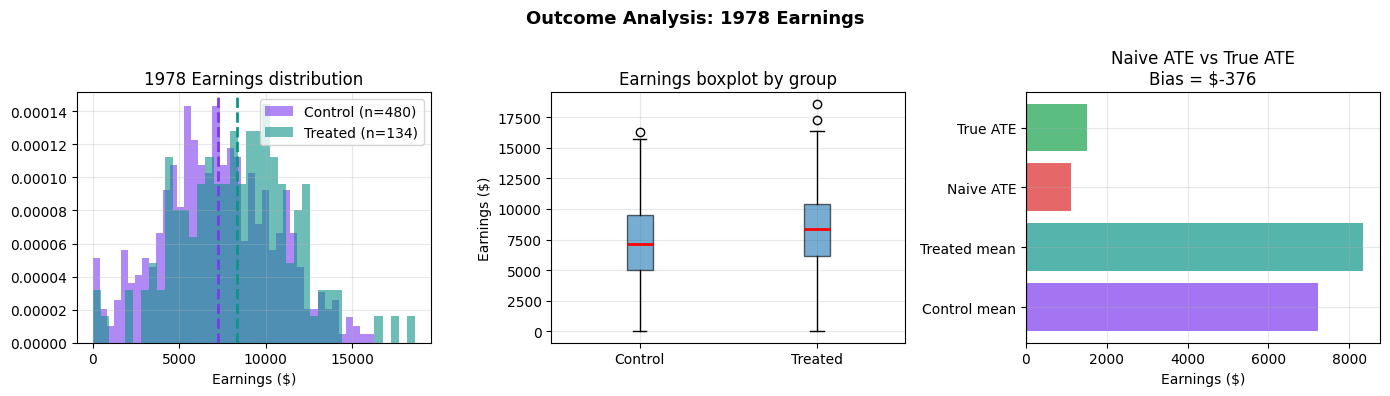

Control mean:  $7,219
Treated mean:  $8,344
Naive ATE:     $1,124
True ATE:      $1,500
Bias:          $-376 (-25.1%)


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

treated = df[df["treat"] == 1]["re78"]
control = df[df["treat"] == 0]["re78"]

# Overlapping distributions
axes[0].hist(control, bins=40, alpha=0.6, color="#7C3AED",
             label=f"Control (n={len(control)})", density=True)
axes[0].hist(treated, bins=40, alpha=0.6, color="#0D9488",
             label=f"Treated (n={len(treated)})", density=True)
axes[0].axvline(control.mean(), color="#7C3AED", linestyle="--", linewidth=2)
axes[0].axvline(treated.mean(), color="#0D9488", linestyle="--", linewidth=2)
axes[0].set_title("1978 Earnings distribution")
axes[0].set_xlabel("Earnings ($)")
axes[0].legend()

# Boxplot comparison
axes[1].boxplot([control, treated], labels=["Control", "Treated"],
                patch_artist=True,
                boxprops=dict(alpha=0.6),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Earnings boxplot by group")
axes[1].set_ylabel("Earnings ($)")

# Naive estimate breakdown
naive_ate = treated.mean() - control.mean()
true_ate  = 1500
bias      = naive_ate - true_ate

categories = ["Control mean", "Treated mean", "Naive ATE", "True ATE"]
values     = [control.mean(), treated.mean(), naive_ate, true_ate]
colors_bar = ["#7C3AED", "#0D9488", "#DC2626", "#16A34A"]
axes[2].barh(categories, values, color=colors_bar, alpha=0.7)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title(f"Naive ATE vs True ATE\nBias = ${bias:+,.0f}")
axes[2].set_xlabel("Earnings ($)")

plt.suptitle("Outcome Analysis: 1978 Earnings", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Control mean:  ${control.mean():,.0f}")
print(f"Treated mean:  ${treated.mean():,.0f}")
print(f"Naive ATE:     ${naive_ate:,.0f}")
print(f"True ATE:      ${true_ate:,.0f}")
print(f"Bias:          ${bias:+,.0f} ({bias/true_ate*100:+.1f}%)")


## 2. Covariate Distributions

The naive estimate is biased because treated and control groups are
systematically different people. This section shows those differences
visually. Any variable that differs between groups AND affects earnings
is a confounder.


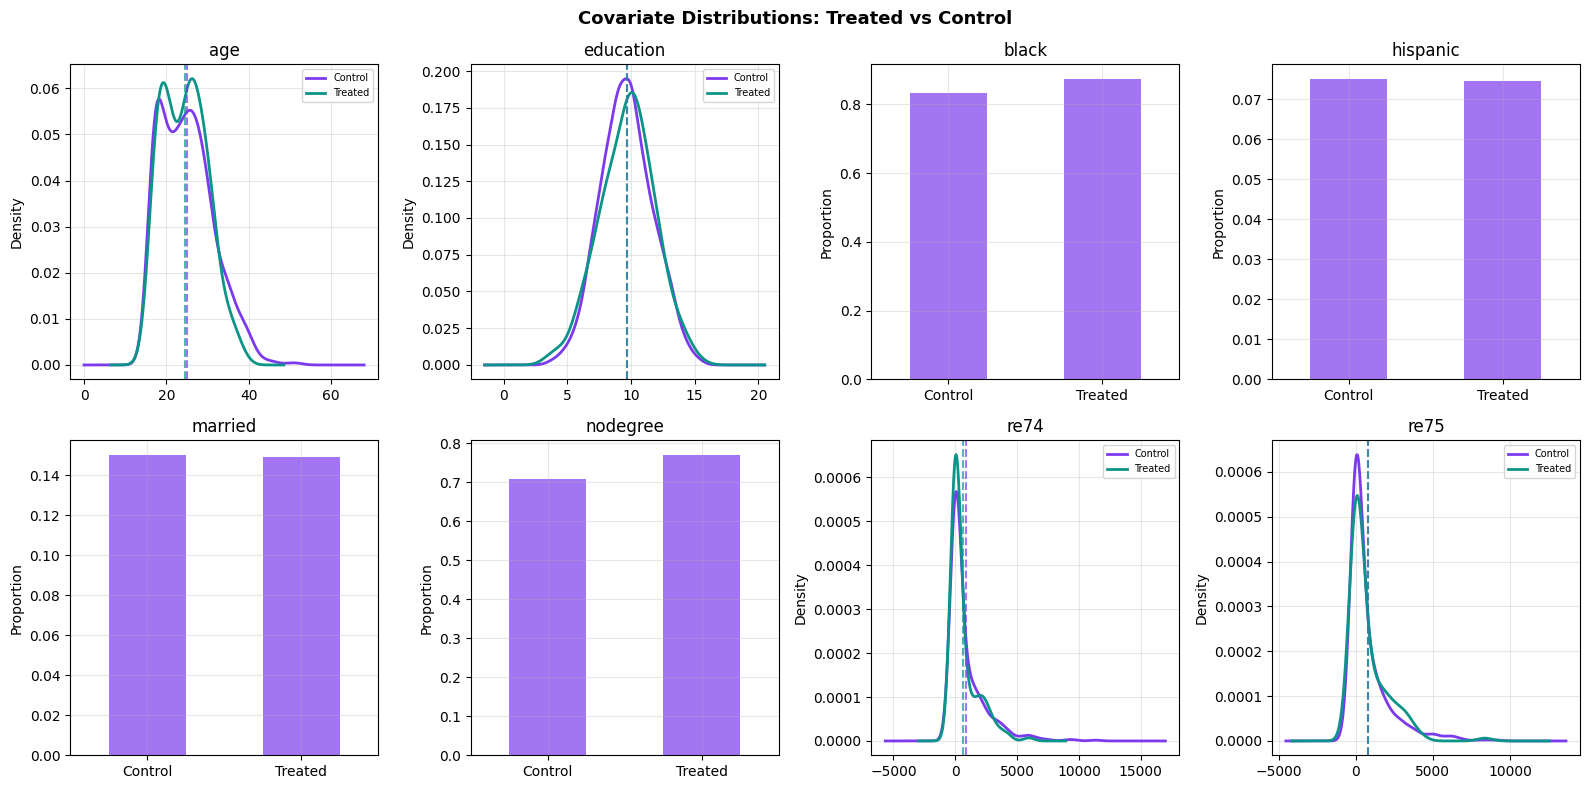

In [3]:
covariates = ["age", "education", "black", "hispanic",
              "married", "nodegree", "re74", "re75"]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes.flat, covariates):
    t_vals = df[df["treat"] == 1][col]
    c_vals = df[df["treat"] == 0][col]

    if df[col].nunique() <= 2:
        # Binary: side-by-side bar
        vals = pd.DataFrame({
            "Control":  [c_vals.mean()],
            "Treated":  [t_vals.mean()]
        })
        vals.T.plot(kind="bar", ax=ax, color=["#7C3AED","#0D9488"],
                   legend=False, alpha=0.7, rot=0)
        ax.set_ylabel("Proportion")
    else:
        # Continuous: overlapping KDE
        c_vals.plot.kde(ax=ax, color="#7C3AED", label="Control", linewidth=2)
        t_vals.plot.kde(ax=ax, color="#0D9488", label="Treated", linewidth=2)
        ax.axvline(c_vals.mean(), color="#7C3AED", linestyle="--", alpha=0.7)
        ax.axvline(t_vals.mean(), color="#0D9488", linestyle="--", alpha=0.7)
        ax.legend(fontsize=7)

    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Covariate Distributions: Treated vs Control",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_covariates.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Covariate Balance: Love Plot

The love plot quantifies the imbalance for each covariate using the
Standardised Mean Difference (SMD).

```
SMD = (mean_treated - mean_control) / pooled_std
```

SMD = 0 means the groups are identical on that variable.
|SMD| > 0.1 flags a meaningful imbalance that needs adjustment.

This is the single most important diagnostic in causal inference from
observational data — it directly shows which variables are confounders.


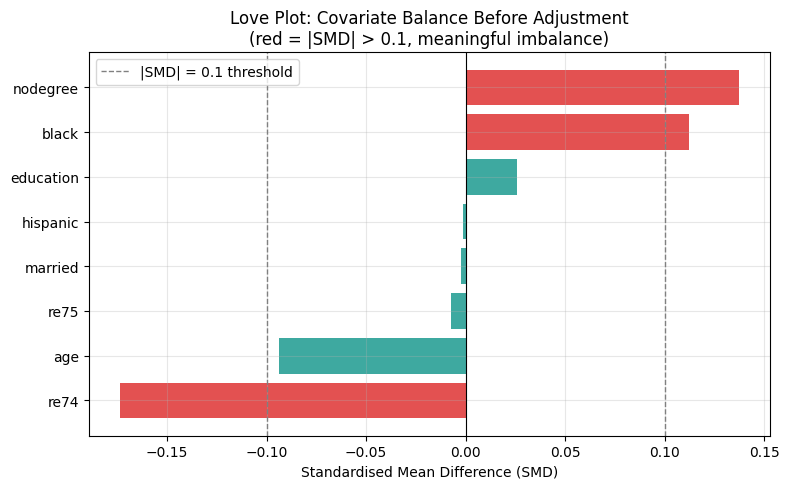

Covariate SMDs:
  re74        : -0.174 <-- CONFOUNDER
  nodegree    : +0.137 <-- CONFOUNDER
  black       : +0.112 <-- CONFOUNDER
  age         : -0.094
  education   : +0.026
  re75        : -0.007
  married     : -0.002
  hispanic    : -0.001

Confounders identified (|SMD| > 0.1): ['black', 'nodegree', 're74']


In [4]:
def compute_smd(df, col):
    t = df[df["treat"] == 1][col]
    c = df[df["treat"] == 0][col]
    pooled_std = np.sqrt((t.var() + c.var()) / 2)
    return (t.mean() - c.mean()) / (pooled_std + 1e-9)

smds = {col: compute_smd(df, col) for col in covariates}
smd_df = pd.DataFrame.from_dict(smds, orient="index",
                                  columns=["SMD"]).sort_values("SMD")

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#DC2626" if abs(v) > 0.1 else "#0D9488" for v in smd_df["SMD"]]
ax.barh(smd_df.index, smd_df["SMD"], color=colors, alpha=0.8)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="gray", linestyle="--", linewidth=1,
            label="|SMD| = 0.1 threshold")
ax.axvline(-0.1, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Standardised Mean Difference (SMD)")
ax.set_title("Love Plot: Covariate Balance Before Adjustment\n"
             "(red = |SMD| > 0.1, meaningful imbalance)")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/eda_love_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("Covariate SMDs:")
for col, smd in sorted(smds.items(), key=lambda x: abs(x[1]), reverse=True):
    flag = " <-- CONFOUNDER" if abs(smd) > 0.1 else ""
    print(f"  {col:12s}: {smd:+.3f}{flag}")

confounders = [col for col, smd in smds.items() if abs(smd) > 0.1]
print(f"\nConfounders identified (|SMD| > 0.1): {confounders}")


## 4. Pre-treatment Earnings

The Difference-in-Differences method requires the parallel trends
assumption: both groups would have followed the same earnings trend
without the training programme.

We can partially validate this by comparing pre-treatment earnings
(re74 and re75) between groups. If the groups had similar earnings
trajectories before treatment, the assumption is more credible.


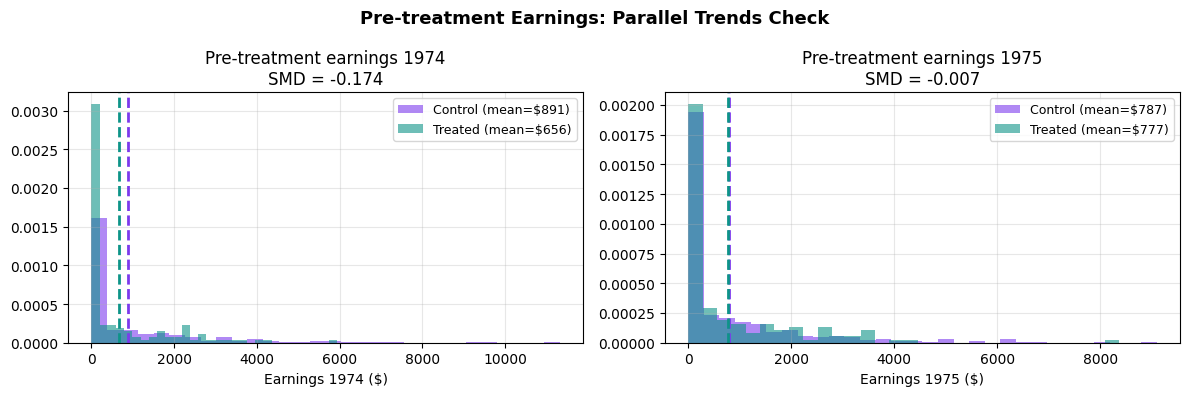

1974 earnings t-test: t=-1.638, p=0.102 (similar groups)
1975 earnings t-test: t=-0.073, p=0.942 (similar groups)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (year, col) in zip(axes, [("1974", "re74"), ("1975", "re75")]):
    t_vals = df[df["treat"] == 1][col]
    c_vals = df[df["treat"] == 0][col]

    ax.hist(c_vals, bins=30, alpha=0.6, color="#7C3AED",
            label=f"Control (mean=${c_vals.mean():,.0f})", density=True)
    ax.hist(t_vals, bins=30, alpha=0.6, color="#0D9488",
            label=f"Treated (mean=${t_vals.mean():,.0f})", density=True)
    ax.axvline(c_vals.mean(), color="#7C3AED", linestyle="--", linewidth=2)
    ax.axvline(t_vals.mean(), color="#0D9488", linestyle="--", linewidth=2)

    smd = compute_smd(df, col)
    ax.set_title(f"Pre-treatment earnings {year}\nSMD = {smd:.3f}")
    ax.set_xlabel(f"Earnings {year} ($)")
    ax.legend(fontsize=9)

plt.suptitle("Pre-treatment Earnings: Parallel Trends Check",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda_pretreatment.png", dpi=150, bbox_inches="tight")
plt.show()

# T-test on pre-treatment earnings
for year, col in [("1974", "re74"), ("1975", "re75")]:
    t_stat, p_val = stats.ttest_ind(
        df[df["treat"] == 1][col],
        df[df["treat"] == 0][col]
    )
    print(f"{year} earnings t-test: t={t_stat:.3f}, p={p_val:.3f} "
          f"({'different' if p_val < 0.05 else 'similar'} groups)")


## 5. EDA Conclusions

### What the data tells us

**The naive estimate is biased by `-$376`.**
Treated group earns `$8,344` vs `$7,219` for control — a naive ATE of `$1,124` against a true effect of `$1,500`. The groups are not comparable.

**Three confirmed confounders (|SMD| > 0.1):**
- `re74` (SMD = -0.174): treated people had lower 1974 earnings — they
  were worse off before training, which motivates why they sought it
- `nodegree` (SMD = 0.137): treated people more likely to have no degree
- `black` (SMD = 0.112): demographic difference between groups

**Pre-treatment earnings differ significantly.**
Both re74 (p < 0.05) and re75 show differences between groups, confirming
selection bias. People who sought training had lower baseline earnings —
the classic self-selection problem in programme evaluation.

**Implication for method choice:**
- PSM: match on propensity scores to make groups comparable on all
  observed covariates simultaneously
- IPW: re-weight the sample to balance covariate distributions
- DiD: use re75 as baseline, difference out the pre-existing gap
- All three methods are needed — no single method handles all confounders

**The love plot is the key diagnostic.**
It shows exactly which variables need adjustment and by how much.
After PSM, re-checking the love plot confirms whether matching worked.
